In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib as mpl

import ipywidgets as widgets

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp
np.random.seed(42)

from pathlib import Path
import soundfile as sf
import json
import subprocess

In [2]:
import UBNA_localize_process_GCC__20260629 as localize

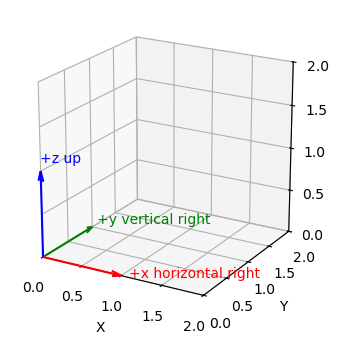

In [3]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(projection="3d")

origin = np.array([0, 0, 0])
axis_len = 1

ax.quiver(*origin, axis_len, 0, 0, color="r", arrow_length_ratio=0.12)
ax.quiver(*origin, 0, axis_len, 0, color="g", arrow_length_ratio=0.12)
ax.quiver(*origin, 0, 0, axis_len, color="b", arrow_length_ratio=0.12)

ax.text(axis_len * 1.1, 0, 0, "+x horizontal right", color="r")
ax.text(0, axis_len * 1.1, 0, "+y vertical right", color="g")
ax.text(0, 0, axis_len * 1.1, "+z up", color="b")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_zlim(0, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=-60)

plt.show()

In [4]:
CUBE_DESIGN = True

In [5]:
A_locs_mat_tdoa = np.array([[0, 0, 0],  #M1 (top left front)
                            [0, 0, -1], #M2 (bottom left front)
                            [1, 0, 0],  #M3 (top right front)
                            [1, 0, -1], #M4 (bottom right front)
                            [0, 1, 0],  #M5 (top left back)
                            [0, 1, -1], #M6 (bottom left back)
                            [1, 1, 0],  #M7 (top right back)
                            [1, 1, -1]])#M8 (bottom right back)
ref_A_loc = A_locs_mat_tdoa[0]
A_locs_mat_tdoa, ref_A_loc

(array([[ 0,  0,  0],
        [ 0,  0, -1],
        [ 1,  0,  0],
        [ 1,  0, -1],
        [ 0,  1,  0],
        [ 0,  1, -1],
        [ 1,  1,  0],
        [ 1,  1, -1]]),
 array([0, 0, 0]))

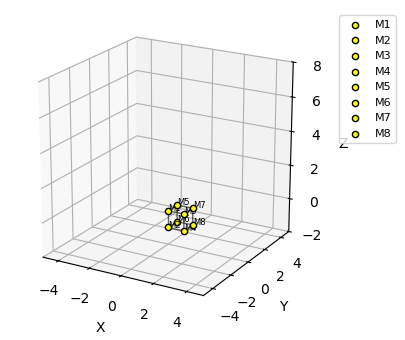

In [6]:
mic_labels = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8"]
edges = [(0, 1), (0, 2), (0, 4), (1, 3), (1, 5), (2, 3), (2, 6), (3, 7), (4, 5), (4, 6), (5, 7), (6, 7)]

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(projection="3d")

for edge_start, edge_end in edges:
    edge_locs = A_locs_mat_tdoa[[edge_start, edge_end]]
    ax.plot(edge_locs[:,0], edge_locs[:,1], edge_locs[:,2], color="black", linewidth=1, alpha=0.6)

for mic_label, mic_loc in zip(mic_labels, A_locs_mat_tdoa):
    ax.scatter(mic_loc[0], mic_loc[1], mic_loc[2], facecolor="yellow", edgecolors="black", label=mic_label)
    ax.text(mic_loc[0], mic_loc[1], mic_loc[2], mic_label, fontsize=6)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-2, 8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=-60)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)

plt.show()

In [7]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [8]:
%matplotlib inline

UBNA_ARRAY_MIC_LOCS = A_locs_mat_tdoa
SELECTED_CHANNEL_FOR_REF = 0
MICROPHONES_USED = np.array([1,2,3,4,5,6,7,8])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
assert(IND_OF_SELECTED_CHANNEL==SELECTED_CHANNEL_FOR_REF)
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

GRID_SIZE = 50
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.2
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10
TEMPLATE_CHANNEL = 3

FS = 250000
ASSUMED_BAT_SPEED = 4*np.sqrt(3)/3 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)

### Simulation #1: TDOA-based method for downchirp transmission using GCC for cube array design

In [9]:
def make_even_sphere_points(num_points=100, radius=20):
    i = np.arange(num_points)
    golden_angle = np.pi * (3 - np.sqrt(5))

    z_dir = 1 - 2 * (i + 0.5) / num_points
    xy_dir = np.sqrt(1 - z_dir**2)
    theta = golden_angle * i

    directions = np.column_stack([xy_dir * np.cos(theta), xy_dir * np.sin(theta), z_dir])
    radii = radius * ((i + 0.5) / num_points)**(1 / 3)

    return directions * radii[:, None]

def make_sphere_surface_points(num_points=100, radius=20):
    i = np.arange(num_points)
    golden_angle = np.pi * (3 - np.sqrt(5))

    z = 1 - 2 * (i + 0.5) / num_points
    xy = np.sqrt(1 - z**2)
    theta = golden_angle * i

    x = radius * xy * np.cos(theta)
    y = radius * xy * np.sin(theta)
    z = radius * z

    return np.column_stack([x, y, z])

In [10]:
%matplotlib widget

def simulate_N_receivers(ascale, sphere_radius, num_pts, noise_power_dB):
    resized_UBNA_ARRAY_MIC_LOCS = ascale * UBNA_ARRAY_MIC_LOCS
    N = resized_UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = resized_UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = resized_UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = resized_UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = resized_UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = sp.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    sphere_surface_points = make_sphere_surface_points(num_points=num_pts, radius=sphere_radius)
    x_arr = sphere_surface_points[:,0]
    y_arr = sphere_surface_points[:,1]
    z_arr = sphere_surface_points[:,2]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = localize.index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            ref_mic_call_only, found_call_start, found_call_dur = localize.extract_reference_call_only(ref_call_of_det, approx_call_dur)

            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
            lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    if measured_d_mics_to_ref.shape[0]>=1:
        source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
        for i in range(measured_d_mics_to_ref.shape[0]-1):
            measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), measured_dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (measured_dm0_column**2))/2
            xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

            source_locs[:,i] = xs[:,0].reshape((1,4))

    map_ax_3d.scatter(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='red', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    map_ax_3d.scatter(x_arr, y_arr, z_arr, color='cyan', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    avg_d_err = (source_locs[0,:]-x_arr[:len(x_arr)-1])**2 + (source_locs[1,:]-y_arr[:len(y_arr)-1])**2 + (source_locs[2,:]-z_arr[:len(z_arr)-1])**2
    avg_d_err = np.sqrt(np.mean(avg_d_err))
    map_ax_3d.text(x=10, y=10, z=25, s=f"Avg. Distance error = {avg_d_err:.6f}", color='k', fontsize=14)
    for i in range(source_locs.shape[1]):
        map_ax_3d.plot([source_locs[0,i], x_arr[i]], [source_locs[1,i], y_arr[i]], [source_locs[2,i], z_arr[i]], color="black", linewidth=0.8, alpha=0.4)
    map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 2, GRID_SIZE /2)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_box_aspect([1, 1, 1])
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')

    plt.show()

as_scale_slider = widgets.FloatSlider(
    value=1, min=0.5, max=5, step=0.1, description=r"Scale factor (α)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

radius_slider = widgets.FloatSlider(
    value=20, min=1, max=25, step=1, description=r"Sphere radius (r)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

num_surface_points_slider = widgets.IntSlider(
    value=100, min=10, max=1000, step=10, description="Number of Surface Points", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, ascale=as_scale_slider, sphere_radius=radius_slider,num_pts=num_surface_points_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=1.0, description='Scale factor (α)', layout=Layout(width='1000px'), ma…

In [11]:
%matplotlib widget

def simulate_N_receivers(ascale, sphere_radius, num_pts, noise_power_dB):
    resized_UBNA_ARRAY_MIC_LOCS = ascale * UBNA_ARRAY_MIC_LOCS
    N = resized_UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = resized_UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = resized_UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = resized_UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = resized_UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = sp.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    sphere_surface_points = make_sphere_surface_points(num_points=num_pts, radius=sphere_radius)
    x_arr = sphere_surface_points[:,0]
    y_arr = sphere_surface_points[:,1]
    z_arr = sphere_surface_points[:,2]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = localize.index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            ref_mic_call_only, found_call_start, found_call_dur = localize.extract_reference_call_only(ref_call_of_det, approx_call_dur)

            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
            lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    if measured_d_mics_to_ref.shape[0]>=1:
        source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
        for i in range(measured_d_mics_to_ref.shape[0]-1):
            measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
            num_noise = 100
            dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
            xs_estimates = np.zeros((num_noise, 4))
            for j in range(num_noise):
                dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
                A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
                wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
                xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)
                xs_estimates[j,:] = xs[:,0]

            mean_xs = np.mean(xs_estimates, axis=0)
            source_locs[:,i] = mean_xs.reshape((1,4))

    map_ax_3d.scatter(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='red', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    map_ax_3d.scatter(x_arr, y_arr, z_arr, color='cyan', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    avg_d_err = (source_locs[0,:]-x_arr[:len(x_arr)-1])**2 + (source_locs[1,:]-y_arr[:len(y_arr)-1])**2 + (source_locs[2,:]-z_arr[:len(z_arr)-1])**2
    avg_d_err = np.sqrt(np.mean(avg_d_err))
    map_ax_3d.text(x=10, y=10, z=25, s=f"Avg. Distance error = {avg_d_err:.6f}", color='k', fontsize=14)
    for i in range(source_locs.shape[1]):
        map_ax_3d.plot([source_locs[0,i], x_arr[i]], [source_locs[1,i], y_arr[i]], [source_locs[2,i], z_arr[i]], color="black", linewidth=0.8, alpha=0.4)
    map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 2, GRID_SIZE /2)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_box_aspect([1, 1, 1])
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')

    plt.show()

as_scale_slider = widgets.FloatSlider(
    value=1, min=0.5, max=5, step=0.1, description=r"Scale factor (α)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

radius_slider = widgets.FloatSlider(
    value=20, min=1, max=25, step=1, description=r"Sphere radius (r)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

num_surface_points_slider = widgets.IntSlider(
    value=100, min=10, max=1000, step=10, description="Number of Surface Points", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, ascale=as_scale_slider, sphere_radius=radius_slider,num_pts=num_surface_points_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=1.0, description='Scale factor (α)', layout=Layout(width='1000px'), ma…

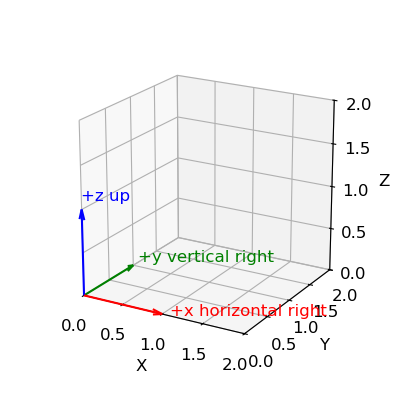

In [ ]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(projection="3d")

origin = np.array([0, 0, 0])
axis_len = 1

ax.quiver(*origin, axis_len, 0, 0, color="r", arrow_length_ratio=0.12)
ax.quiver(*origin, 0, axis_len, 0, color="g", arrow_length_ratio=0.12)
ax.quiver(*origin, 0, 0, axis_len, color="b", arrow_length_ratio=0.12)

ax.text(axis_len * 1.1, 0, 0, "+x horizontal right", color="r")
ax.text(0, axis_len * 1.1, 0, "+y vertical right", color="g")
ax.text(0, 0, axis_len * 1.1, "+z up", color="b")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_zlim(0, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=-60)

plt.show()

In [ ]:
ARRAYCROSS_DESIGN = True

In [ ]:
A_locs_mat_tdoa = np.array([[0,  0,  0],    #M1 (front center middle)
                            [0, -1, 1],     #M2 (back middle top)
                            [-1, -1, 0],    #M3 (back center left)
                            [1, -1, 0],     #M4 (back center right)
                            [0, -1, -1]])   #M5 (back middle bottom)
ref_A_loc = A_locs_mat_tdoa[0]
A_locs_mat_tdoa, ref_A_loc

(array([[ 0,  0,  0],
        [ 0, -1,  1],
        [-1, -1,  0],
        [ 1, -1,  0],
        [ 0, -1, -1]]),
 array([0, 0, 0]))

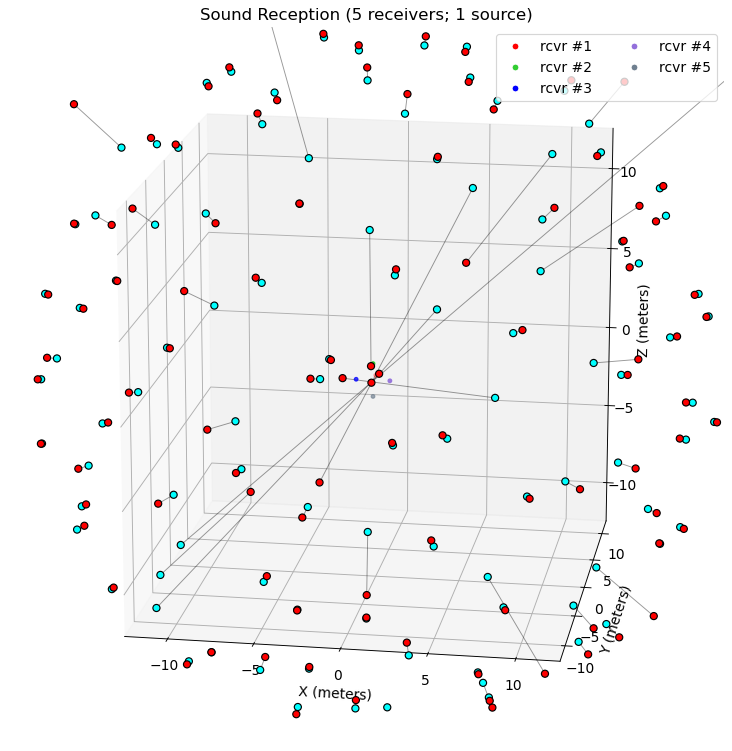

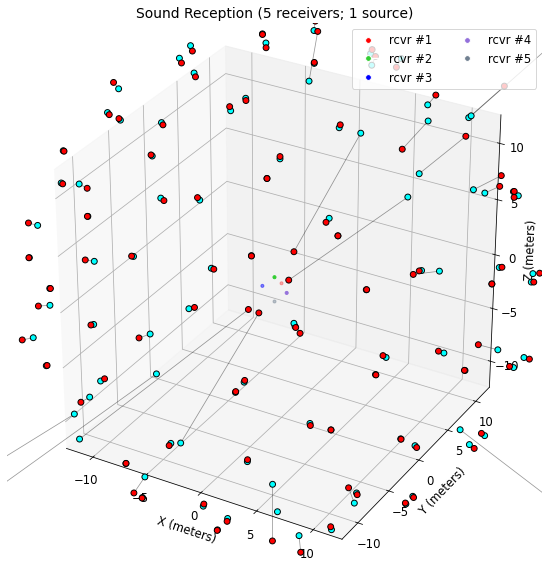

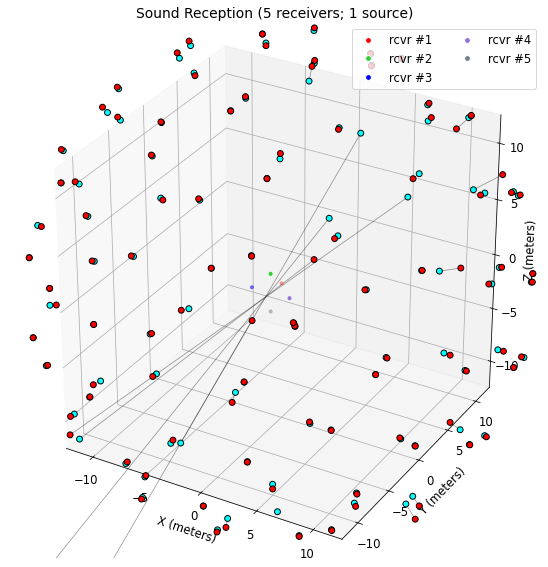

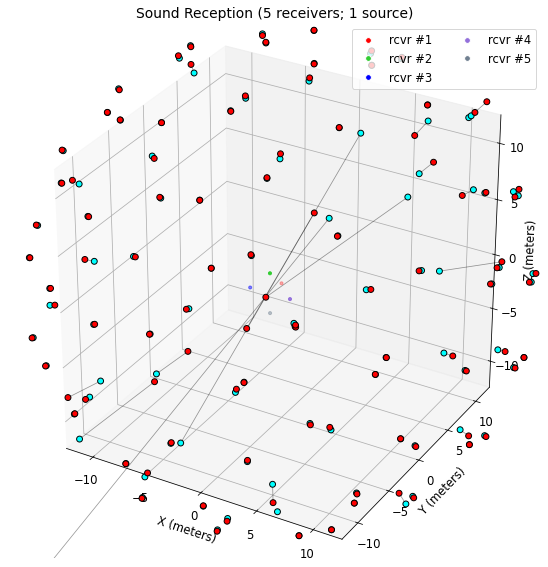

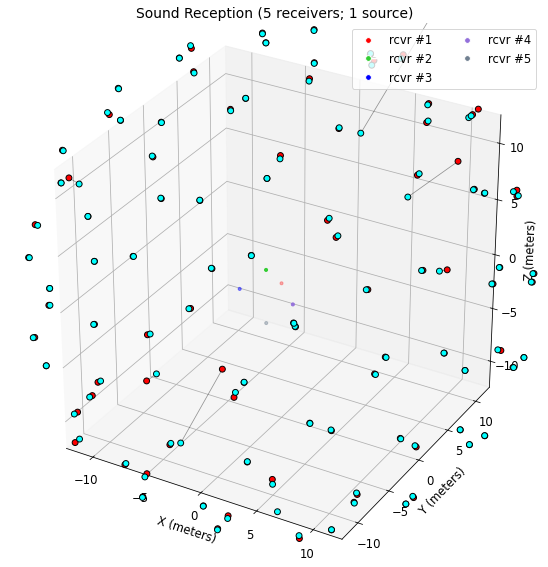

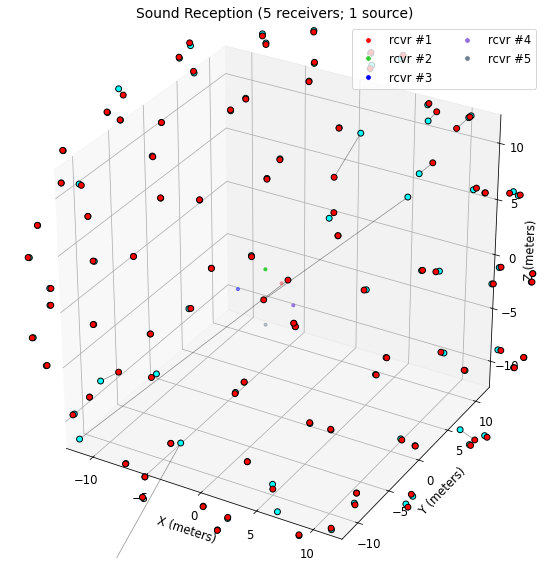

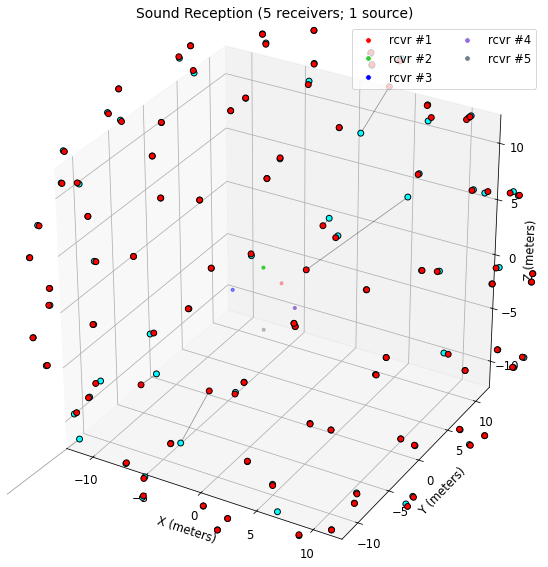

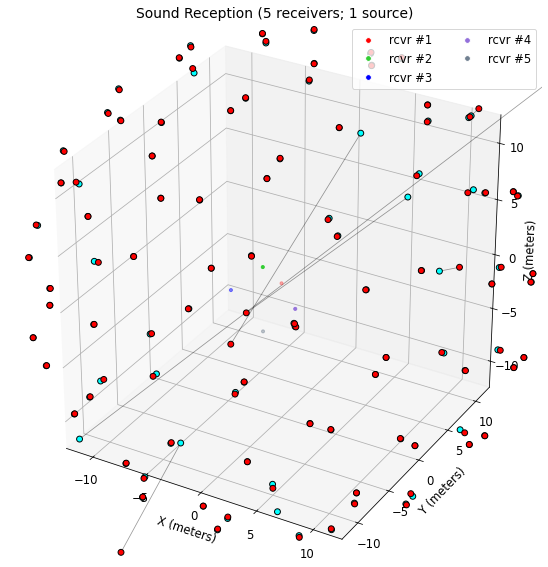

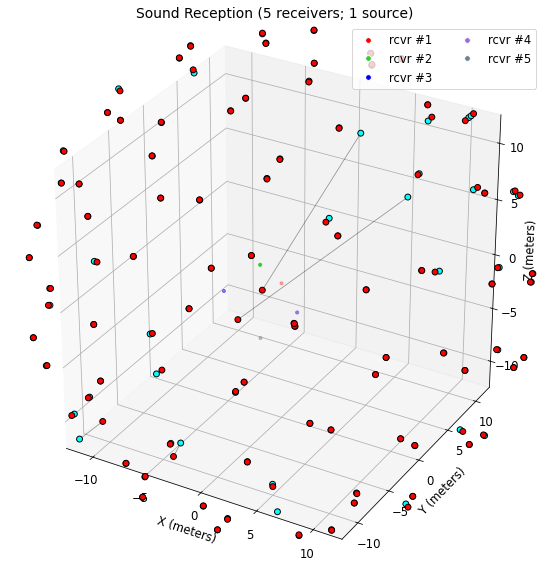

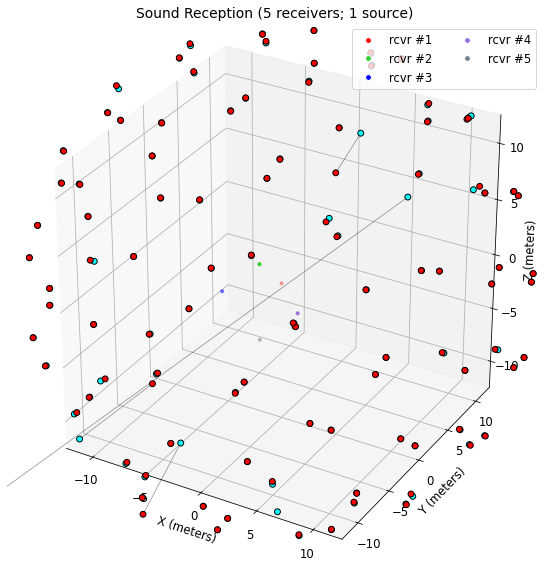

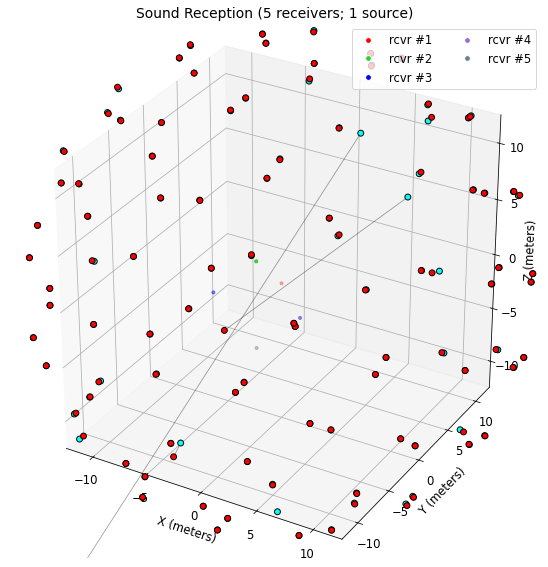

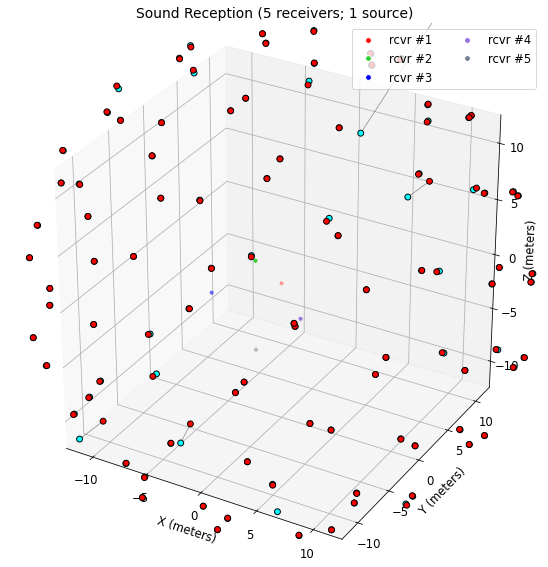

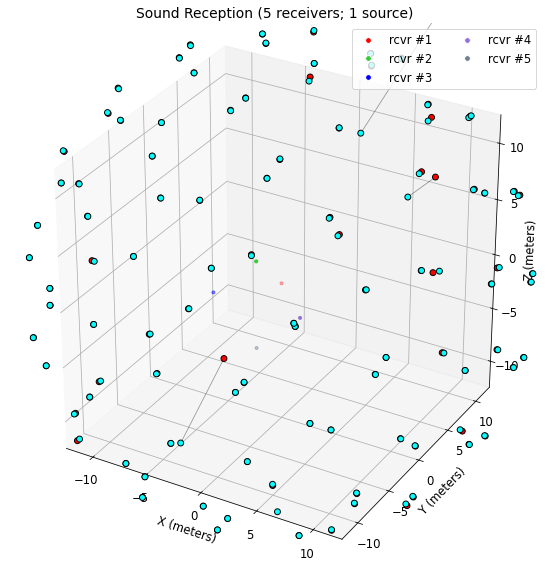

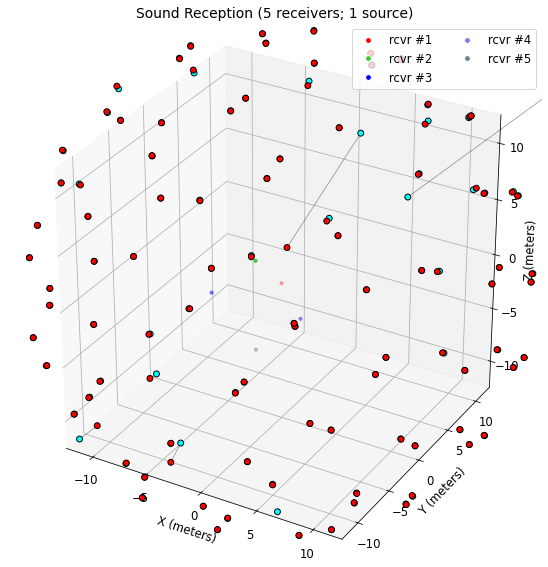

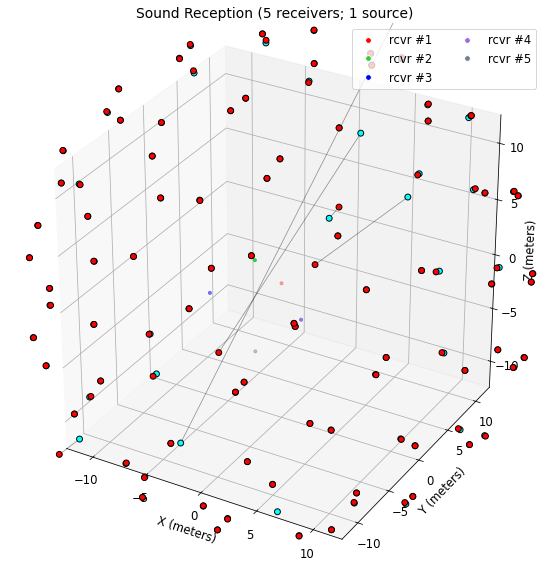

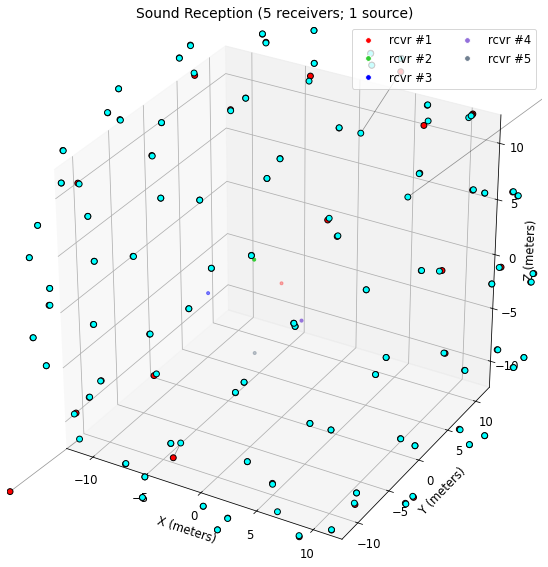

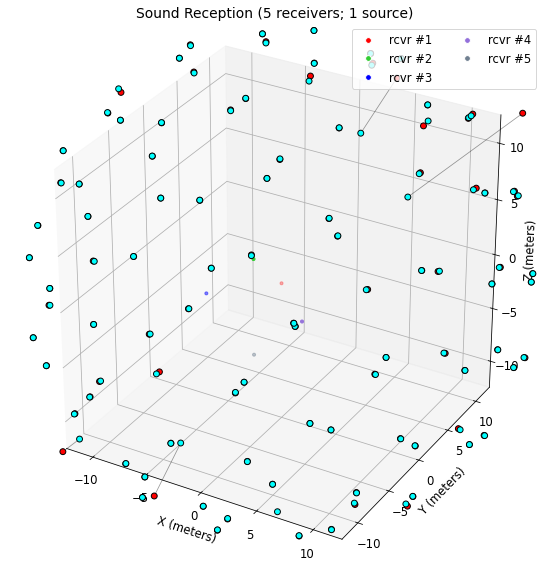

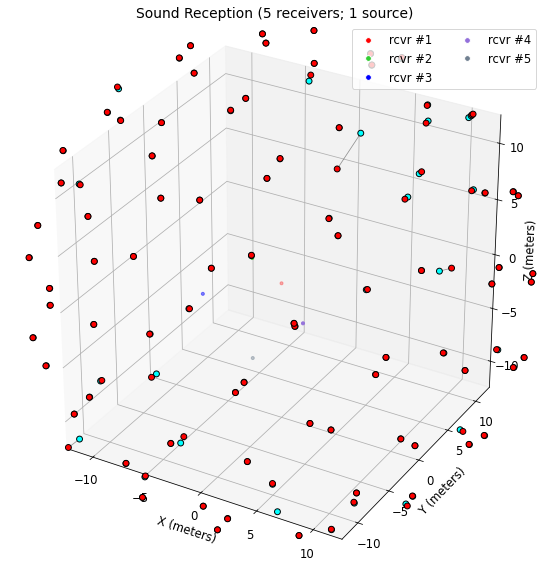

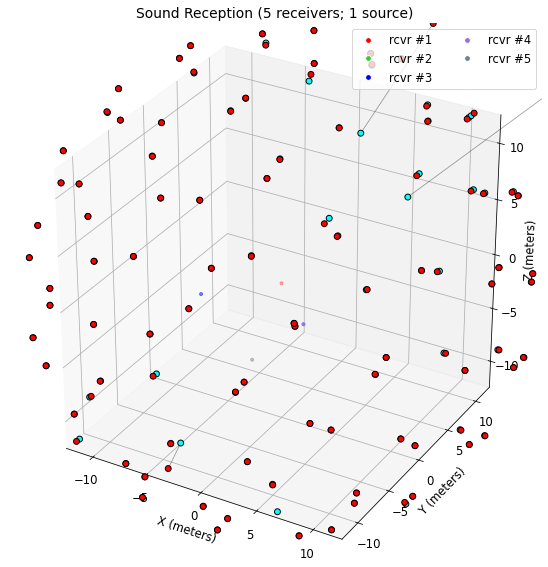

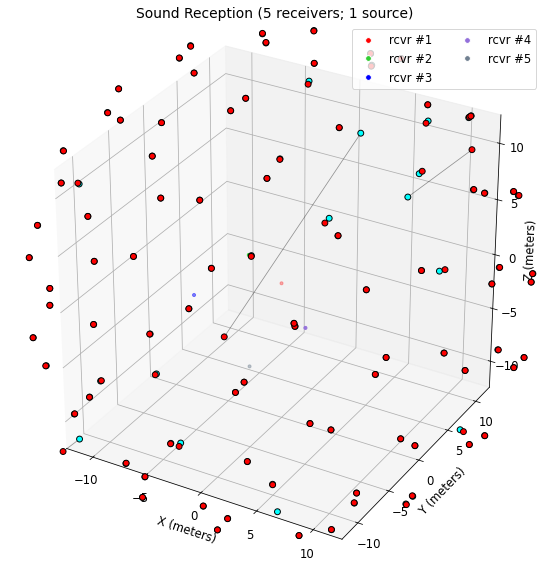

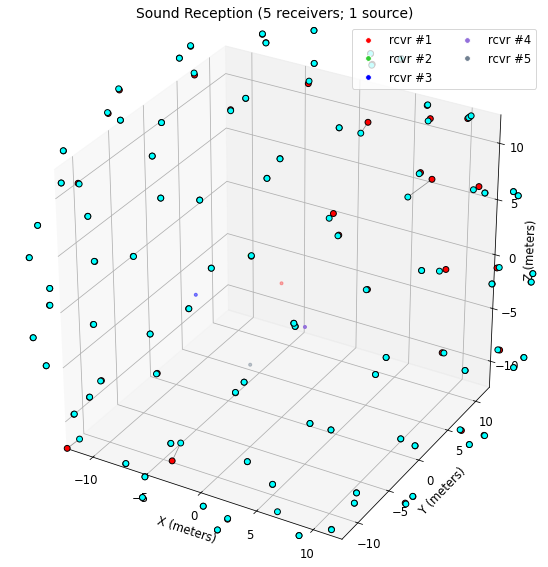

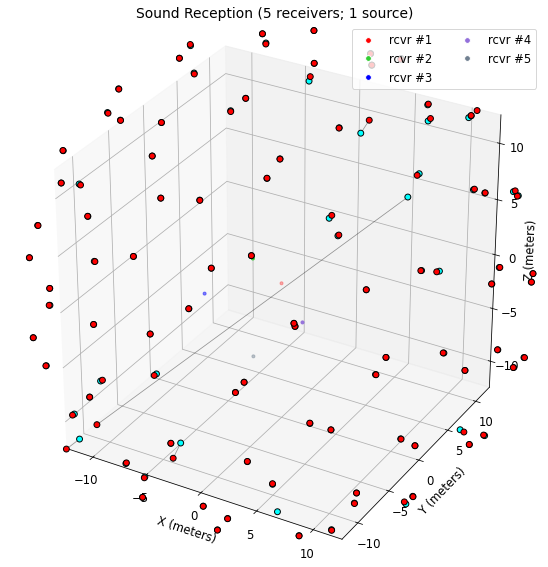

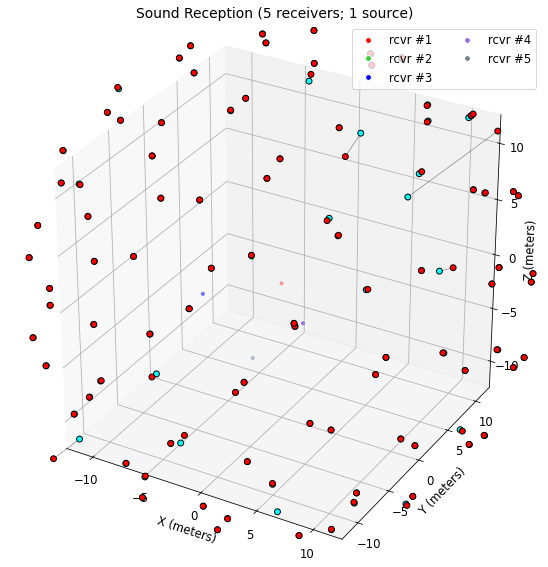

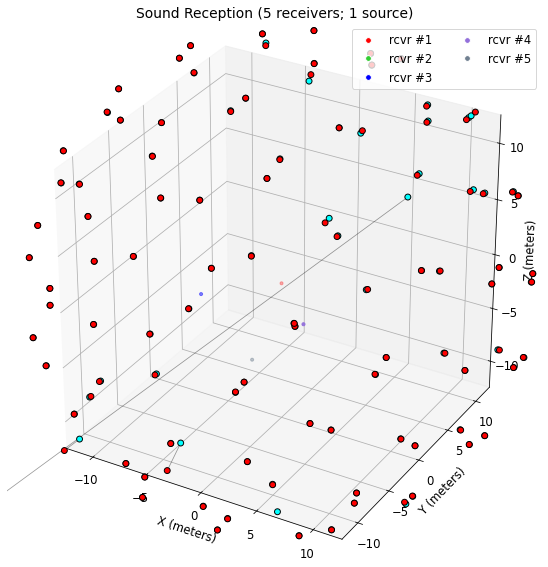

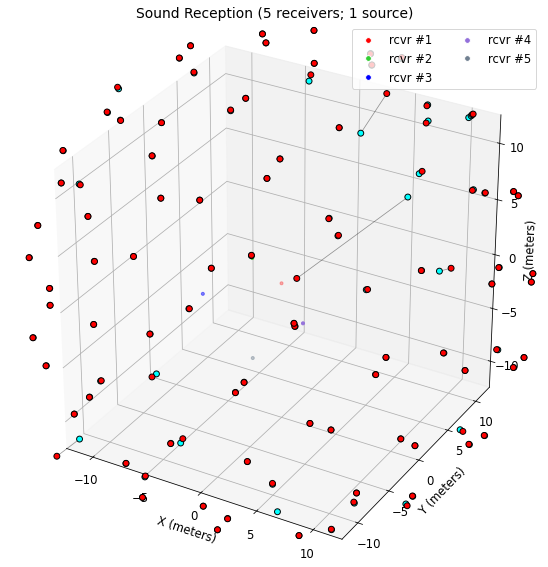

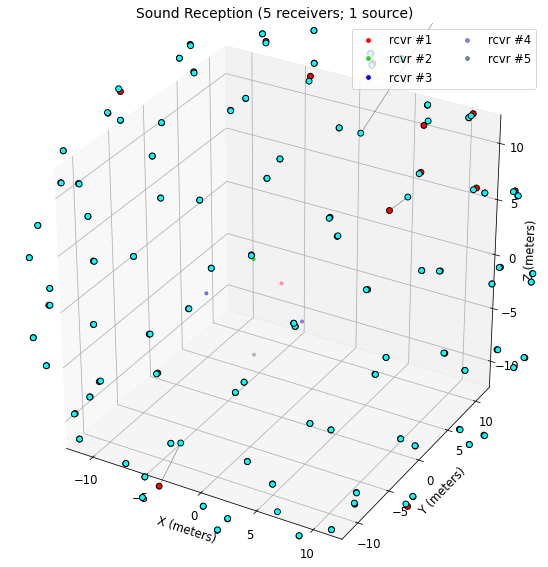

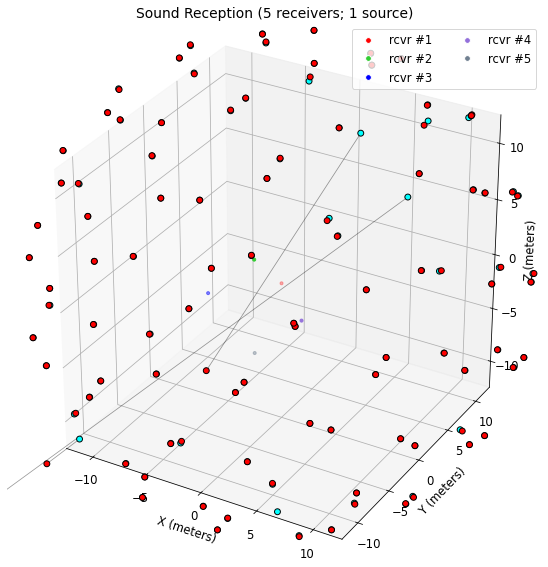

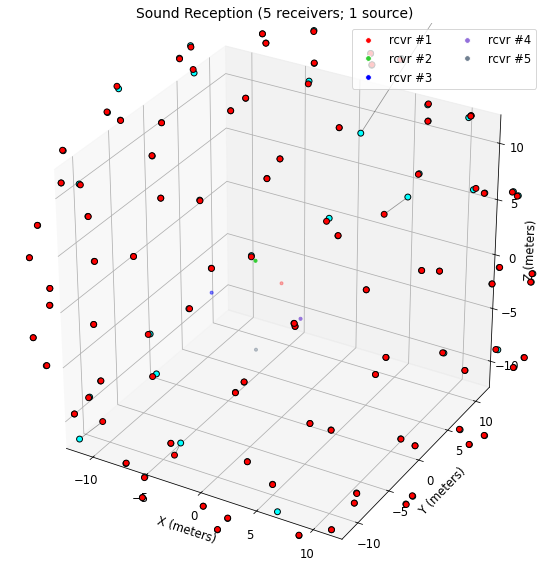

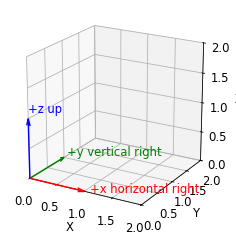

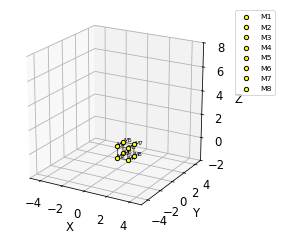

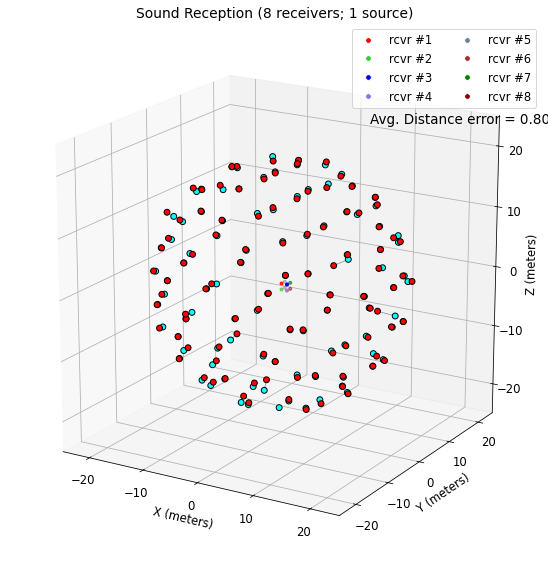

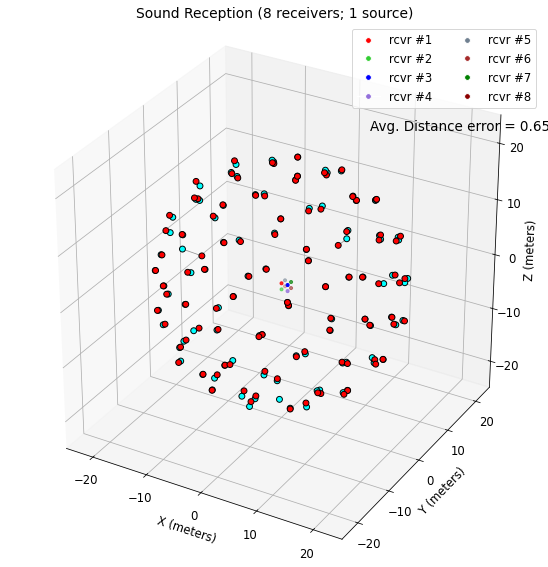

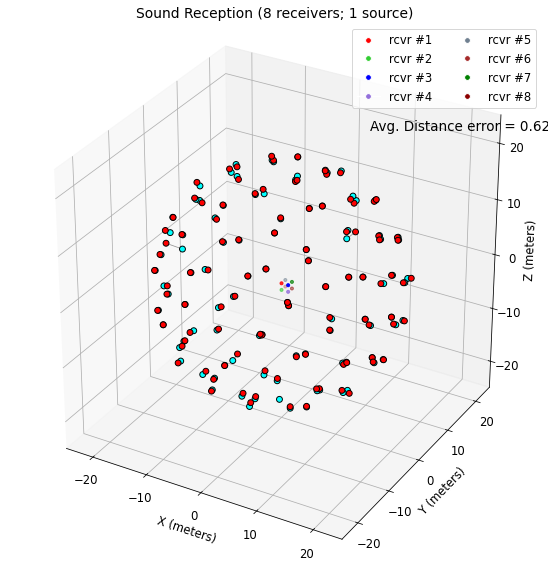

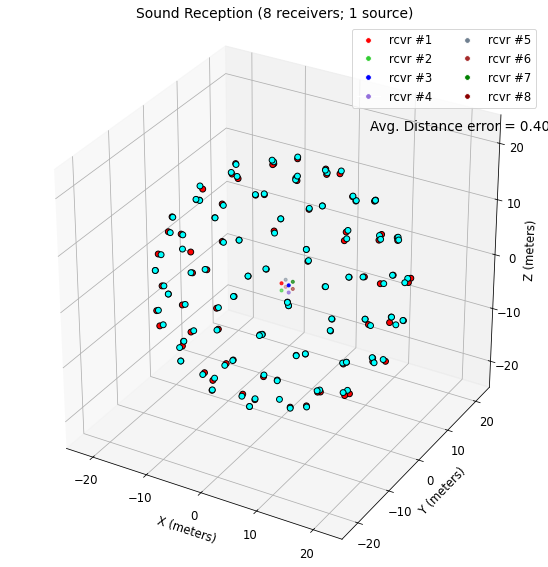

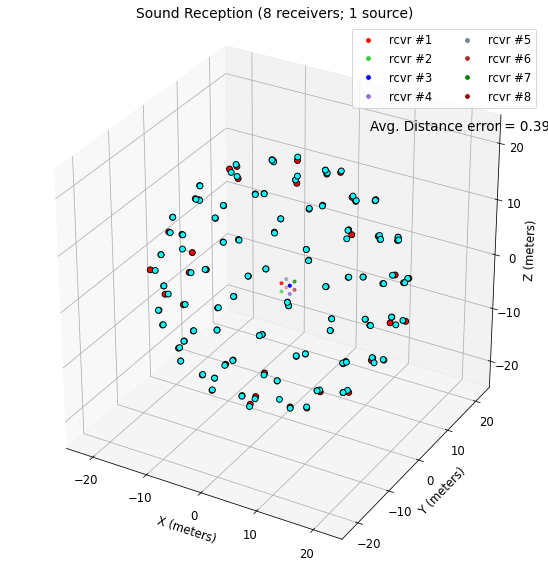

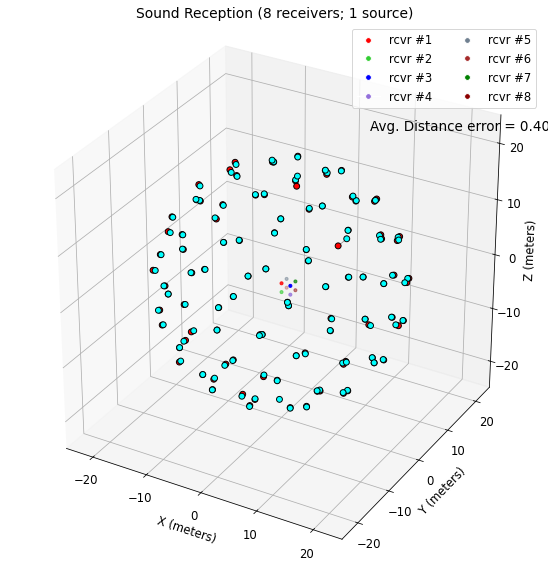

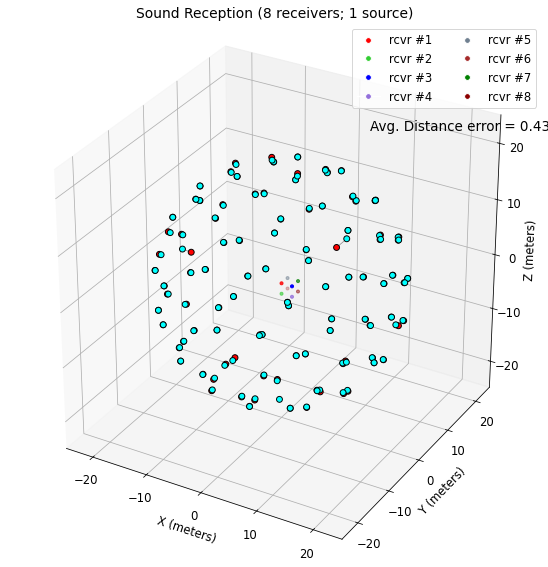

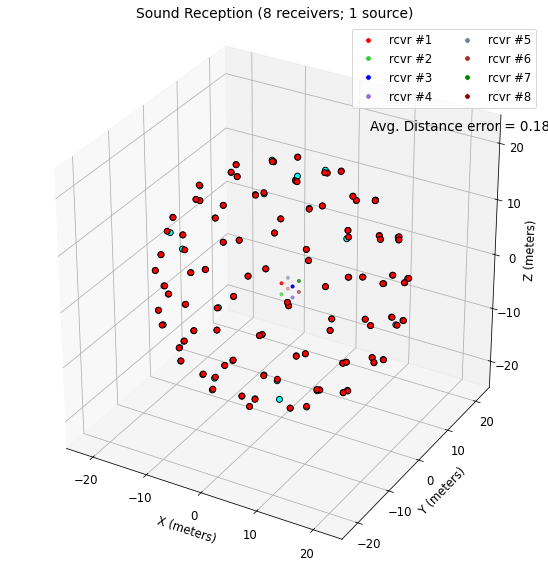

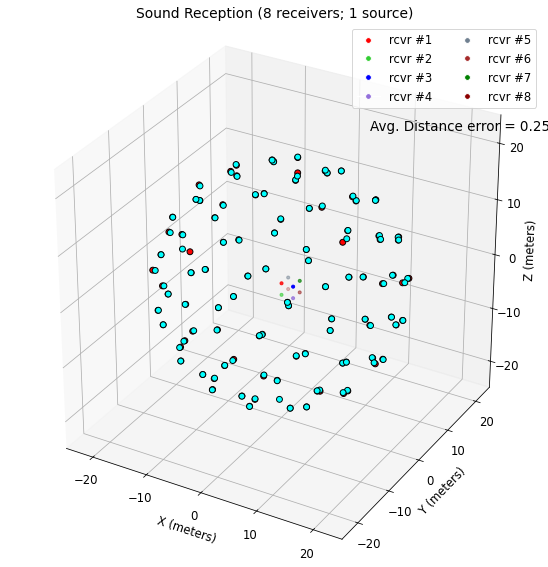

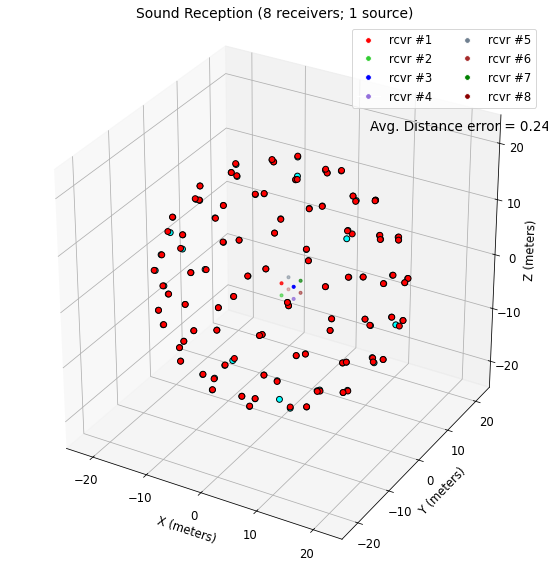

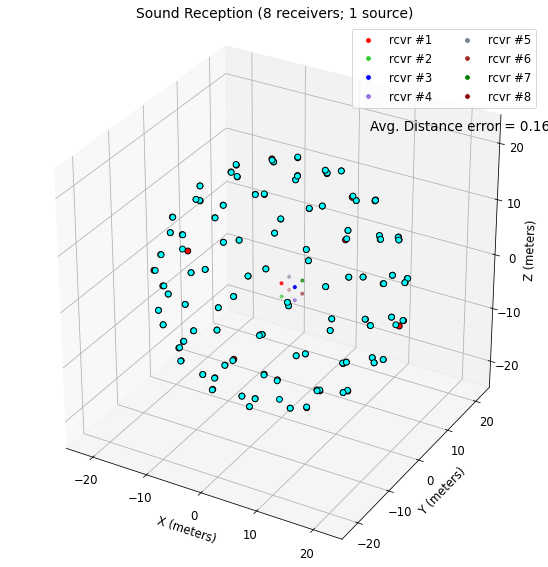

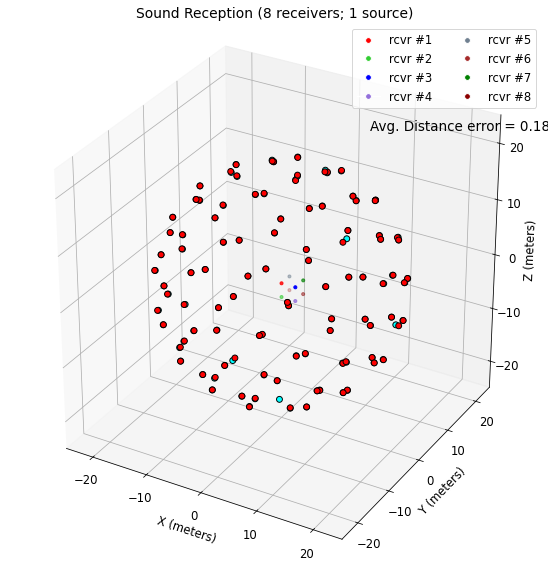

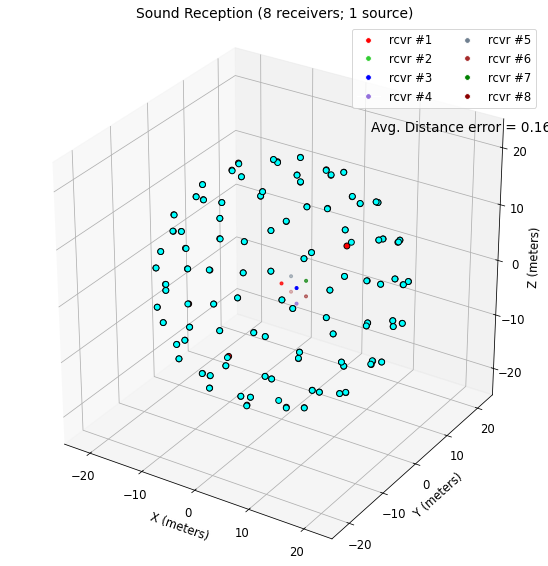

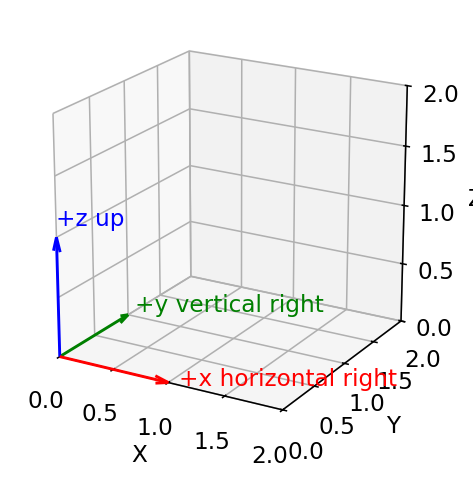

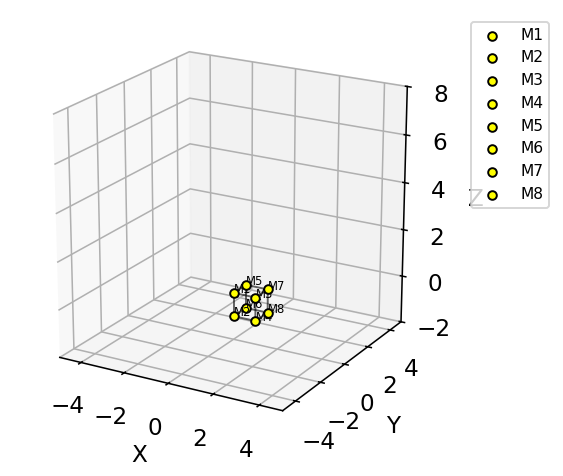

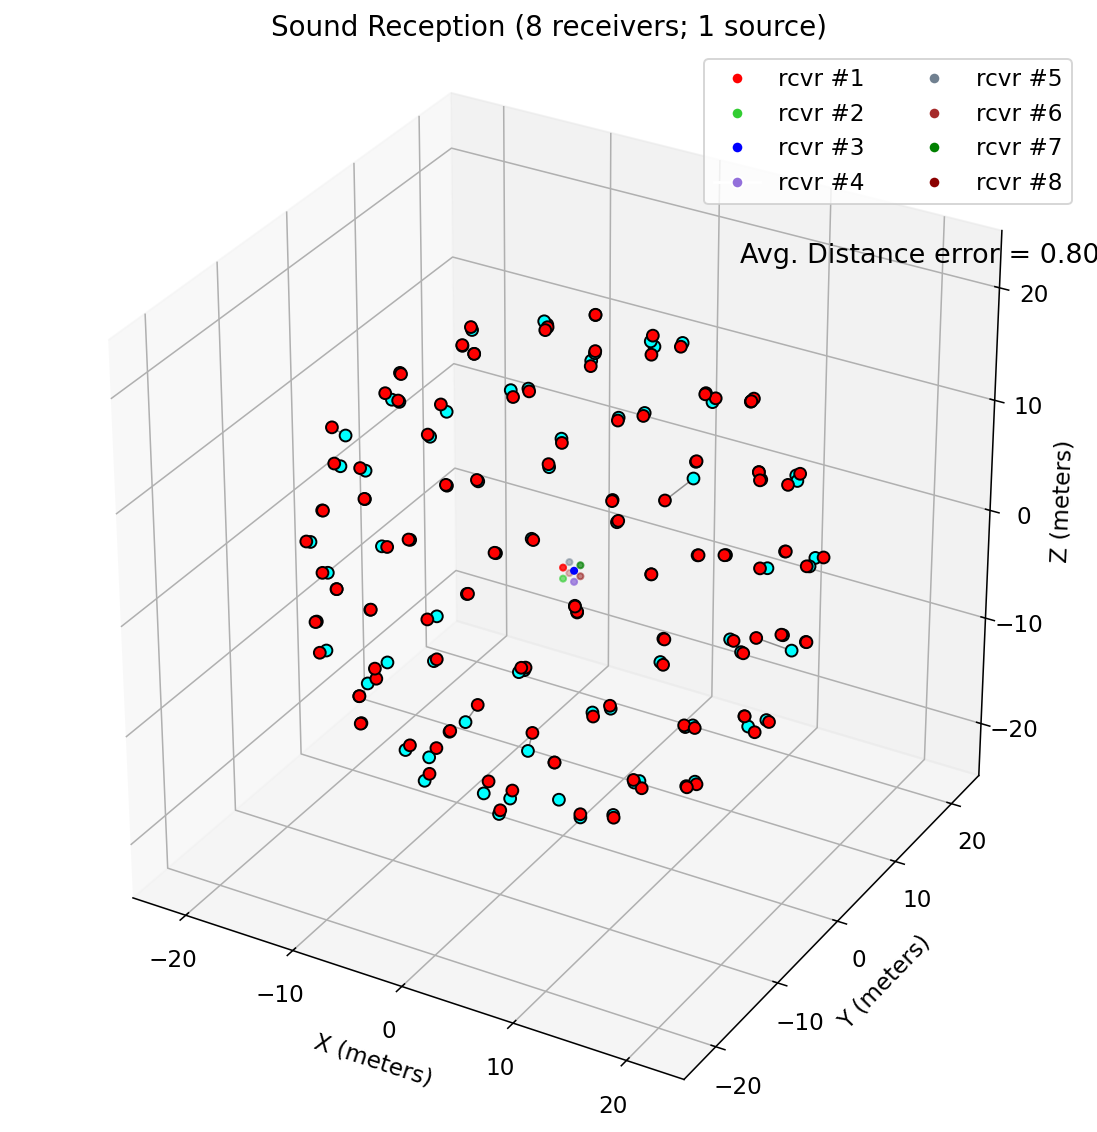

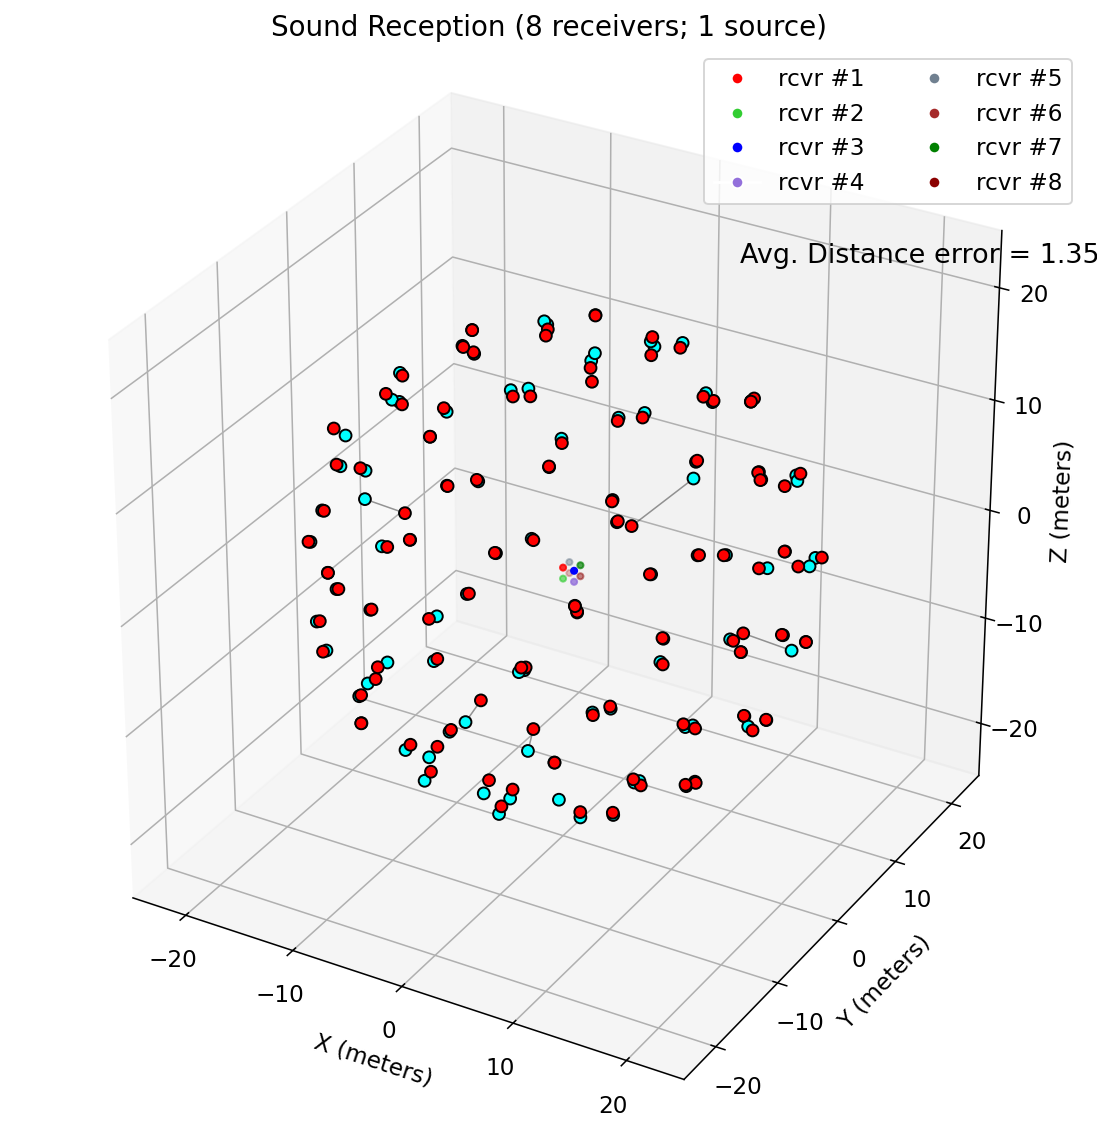

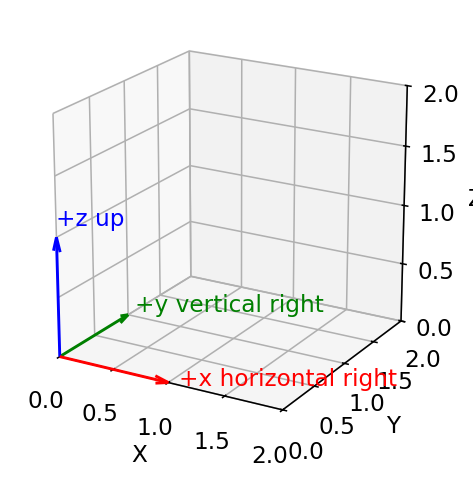

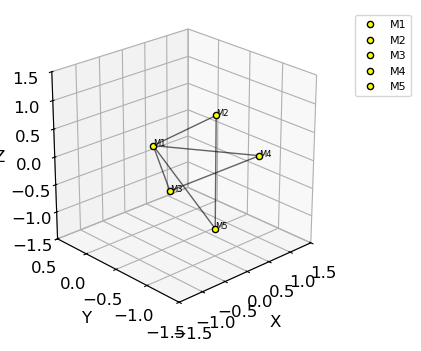

In [ ]:
mic_labels = ["M1", "M2", "M3", "M4", "M5"]
edges = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 3)]

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(projection="3d")

for edge_start, edge_end in edges:
    edge_locs = A_locs_mat_tdoa[[edge_start, edge_end]]
    ax.plot(edge_locs[:,0], edge_locs[:,1], edge_locs[:,2], color="black", linewidth=1, alpha=0.6)

for mic_label, mic_loc in zip(mic_labels, A_locs_mat_tdoa):
    ax.scatter(mic_loc[0], mic_loc[1], mic_loc[2], facecolor="yellow", edgecolors="black", label=mic_label)
    ax.text(mic_loc[0], mic_loc[1], mic_loc[2], mic_label, fontsize=6)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 0.5)
ax.set_zlim(-1.5, 1.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=24, azim=-133)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)

plt.show()

In [ ]:
%matplotlib inline

UBNA_ARRAY_MIC_LOCS = A_locs_mat_tdoa
SELECTED_CHANNEL_FOR_REF = 0
MICROPHONES_USED = np.array([1,2,3,4,5])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
assert(IND_OF_SELECTED_CHANNEL==SELECTED_CHANNEL_FOR_REF)
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

GRID_SIZE = 25
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.2
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10
TEMPLATE_CHANNEL = 3

FS = 250000
ASSUMED_BAT_SPEED = 4*np.sqrt(3)/3 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)

### Simulation #1: TDOA-based method for downchirp transmission using GCC for cross array design

In [ ]:
%matplotlib widget

def simulate_N_receivers(ascale, sphere_radius, num_pts, noise_power_dB):
    resized_UBNA_ARRAY_MIC_LOCS = ascale * UBNA_ARRAY_MIC_LOCS
    N = resized_UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = resized_UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = resized_UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = resized_UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = resized_UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = sp.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    sphere_surface_points = make_sphere_surface_points(num_points=num_pts, radius=sphere_radius)
    x_arr = sphere_surface_points[:,0]
    y_arr = sphere_surface_points[:,1]
    z_arr = sphere_surface_points[:,2]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = localize.index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            ref_mic_call_only, found_call_start, found_call_dur = localize.extract_reference_call_only(ref_call_of_det, approx_call_dur)

            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
            lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    if measured_d_mics_to_ref.shape[0]>=1:
        source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
        for i in range(measured_d_mics_to_ref.shape[0]-1):
            measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
            num_noise = 100
            dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
            xs_estimates = np.zeros((num_noise, 4))
            for j in range(num_noise):
                dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
                A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
                wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
                xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)
                xs_estimates[j,:] = xs[:,0]

            mean_xs = np.mean(xs_estimates, axis=0)
            source_locs[:,i] = mean_xs.reshape((1,4))

    map_ax_3d.scatter(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='red', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    map_ax_3d.scatter(x_arr, y_arr, z_arr, color='cyan', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    avg_d_err = (source_locs[0,:]-x_arr[:len(x_arr)-1])**2 + (source_locs[1,:]-y_arr[:len(y_arr)-1])**2 + (source_locs[2,:]-z_arr[:len(z_arr)-1])**2
    avg_d_err = np.sqrt(np.mean(avg_d_err))
    map_ax_3d.text(x=10, y=10, z=25, s=f"Avg. Distance error = {avg_d_err:.6f}", color='k', fontsize=14)
    for i in range(source_locs.shape[1]):
        map_ax_3d.plot([source_locs[0,i], x_arr[i]], [source_locs[1,i], y_arr[i]], [source_locs[2,i], z_arr[i]], color="black", linewidth=0.8, alpha=0.4)
    map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 2, GRID_SIZE /2)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_box_aspect([1, 1, 1])
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')

    plt.show()

as_scale_slider = widgets.FloatSlider(
    value=1, min=0.5, max=5, step=0.1, description=r"Scale factor (α)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

radius_slider = widgets.FloatSlider(
    value=20, min=1, max=25, step=1, description=r"Sphere radius (r)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

num_surface_points_slider = widgets.IntSlider(
    value=100, min=10, max=1000, step=10, description="Number of Surface Points", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, ascale=as_scale_slider, sphere_radius=radius_slider,num_pts=num_surface_points_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=1.0, description='Scale factor (α)', layout=Layout(width='1000px'), ma…